# 07 · Внешняя проверка: «Список 100» организаторов и устройство моделей

**Зачем этот шаг.** Метрики 04 и 06 меряют, насколько модель воспроизводит
разметку LLM на отложенных технологиях. Это проверка «изнутри». Здесь —
проверка «снаружи»: организаторы дали 100 технологий, которые методологи в
сентябре 2026 считают слабыми сигналами. Если модель полезна, эти
технологии должны получать у неё высокие оценки.

**Как устроена сверка** (`src/lctrend/modeling/labeling/benchmark.py`).
Каждое описание из списка (по-русски, с пояснением «почему слабый сигнал»)
превращается в эмбеддинг той же моделью, что и понятия графа
(`EmbeddingsGigaR`), и сравнивается со всеми технологиями графа по
косинусу. Ближайшая технология — кандидат, а не доказанное совпадение:
`match_cosine` говорит, насколько он близок.

**Что важно помнить.** В списке только положительные примеры, поэтому он
меряет *полноту* («находим ли мы то, что нашли методологи»), но не
точность.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from lab import *
from IPython.display import display, Markdown
from catboost import CatBoostClassifier

bench = read(RUN_DIR / "benchmark.csv")
years = read(DATASET_DIR / "llm_labels_by_year.csv")
latest = years.sort_values("year").drop_duplicates("technology_id", keep="last")
WEAK = CONFIG["labels"]["weak_max"]
display(Markdown(
    f"Список: **{len(bench)}** технологий в {bench.domain.nunique()} доменах; "
    f"разметка LLM: **{num(len(latest))}** технологий графа."
))
display(bench.domain.value_counts().rename_axis("домен").to_frame("технологий"))

Список: **100** технологий в 6 доменах; разметка LLM: **3 105** технологий графа.

,технологий
домен,
Инфраструктура ИИ,17
Индустриальный ИИ,17
Роботы,17
Финтех,17
Защита ИИ,16
Edge,16


## 1. Нашлись ли технологии списка в графе

**Как читать.** Косинус 1 — тот же смысл; около 0,85 — почти то же
самое; ниже 0,8 — скорее соседняя тема, чем та же технология. Столбики
левее пунктира — технологии, которых в графе, по-видимому, нет.

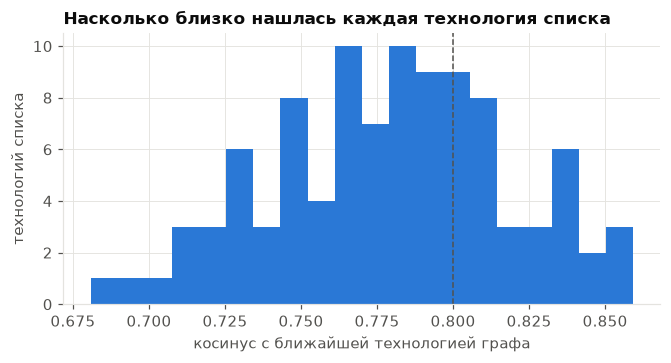

,технологий списка
порог косинуса,
0.75,77
0.80,32
0.85,3


,из списка,ближайшая в графе,косинус
0,Фотонные (оптические) процессоры инференса для компактных…,Photonic Neural Networks,0.8592
1,Confidential computing на слабых edge-устройствах (TEE + удалённая…,Privacy-Preserving Machine Learning inference platform with…,0.8524
2,Wafer-scale нового поколения: 3D-стек SRAM/DRAM поверх пластины,3D-stacked DRAM (HMC-like) with vaults,0.8523
3,LLM-генерация кода ПЛК на IEC 61131-3 Structured Text с замыканием на…,LLM4PLC,0.8475
4,Аналоговые вычисления в памяти (analog in-memory computing),Analog Compute-in-Memory (ACiM) for edge AI,0.8414
5,Депозитные токены банков на публичных блокчейнах,Synthetic CBDC,0.8409
6,Оркестрация Edge AI на парках из тысяч устройств (control plane для…,End-edge-cloud orchestrated architecture for flexible AIoT…,0.8397
7,"Машинные микроплатежи по HTTP 402 (оплата за API-вызов, стриминговые…",HTTP 402 Payment Required with X402/H402 extensions,0.8381
8,"Агентные (multi-step) AI-workflow, исполняемые локально на NPU ПК",Автономные AI-агенты с модульными наборами инструментов,0.8363
9,"3D-стековая память-вычислитель как альтернатива HBM (3DIMC, стековый…",3D-stacked DRAM (HMC-like) with vaults,0.8342


In [2]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(bench.match_cosine, bins=20, color=BLUE)
ax.axvline(0.8, color=MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("косинус с ближайшей технологией графа")
ax.set_ylabel("технологий списка")
ax.set_title("Насколько близко нашлась каждая технология списка")
plt.show()
coverage = pd.DataFrame({
    "порог косинуса": [0.75, 0.8, 0.85],
    "технологий списка": [int((bench.match_cosine >= t).sum()) for t in (0.75, 0.8, 0.85)],
})
display(coverage.set_index("порог косинуса"))
display(bench.sort_values("match_cosine", ascending=False)
        .head(12)[["technology", "graph_technology", "match_cosine"]]
        .assign(technology=lambda d: d.technology.map(lambda t: short(t, 70)),
                graph_technology=lambda d: d.graph_technology.map(lambda t: short(t, 60)))
        .rename(columns={"technology": "из списка", "graph_technology": "ближайшая в графе",
                         "match_cosine": "косинус"}).reset_index(drop=True))

## 2. Что о них говорит модель

**Как читать.** Для технологий, у которых есть оценка модели (они есть в
последней выгрузке), — распределение вероятности слабого сигнала. Если бы
модель узнавала сигналы методологов, заметная часть лежала бы правее 0,5.

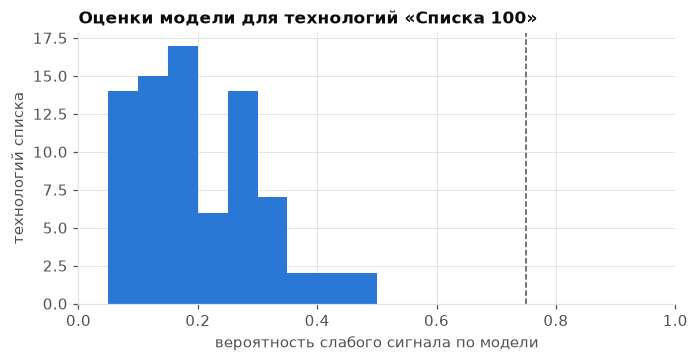

,все сопоставленные,"косинус ≥ 0,8"
с оценкой модели,79.000,27.000
средняя вероятность,0.204,0.219
максимум,0.499,0.471
"вероятность ≥ 0,5",0.000,0.000
выше порога модели,0.000,0.000


In [3]:
scored = bench[bench.in_scores.astype(str) == "True"].copy()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(scored.probability, bins=[i / 20 for i in range(21)], color=BLUE)
ax.axvline(0.75, color=MUTED, linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel("вероятность слабого сигнала по модели")
ax.set_ylabel("технологий списка")
ax.set_title("Оценки модели для технологий «Списка 100»")
plt.show()
close = scored[scored.match_cosine >= 0.8]
summary = pd.DataFrame({
    "все сопоставленные": [len(scored), scored.probability.mean(), scored.probability.max(),
                           int((scored.probability >= 0.5).sum()), int(scored.signal.fillna(0).sum())],
    "косинус ≥ 0,8": [len(close), close.probability.mean(), close.probability.max(),
                      int((close.probability >= 0.5).sum()), int(close.signal.fillna(0).sum())],
}, index=["с оценкой модели", "средняя вероятность", "максимум", "вероятность ≥ 0,5", "выше порога модели"])
display(summary.round(3))

## 3. Что о них говорит LLM — и чем это отличается от всего графа

**Как читать.** Слева — вердикты LLM по технологиям списка, справа — по
всем технологиям графа. «Слабый сигнал по LLM» — оценка последнего года
не больше порога разметки.

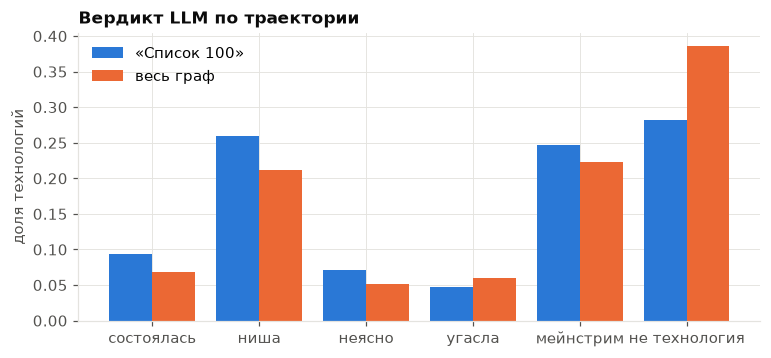

,«Список 100»,технологии графа
с оценкой LLM,85.000,1917.000
доля «слабый сигнал» в последнем году,0.059,0.065


In [4]:
verdicts = ["success", "niche", "unclear", "faded", "mainstream", "junk"]
NAMES = {"success": "состоялась", "niche": "ниша", "unclear": "неясно",
         "faded": "угасла", "mainstream": "мейнстрим", "junk": "не технология"}
listed = bench.llm_verdict.value_counts(normalize=True).reindex(verdicts).fillna(0)
graph = latest.llm_verdict.value_counts(normalize=True).reindex(verdicts).fillna(0)
share = pd.DataFrame({"«Список 100»": listed, "весь граф": graph}).rename(index=NAMES)
fig, ax = plt.subplots(figsize=(8, 3.4))
x = range(len(share))
ax.bar([i - 0.2 for i in x], share["«Список 100»"], width=0.4, label="«Список 100»")
ax.bar([i + 0.2 for i in x], share["весь граф"], width=0.4, label="весь граф")
ax.set_xticks(list(x), share.index)
ax.set_ylabel("доля технологий")
ax.set_title("Вердикт LLM по траектории")
ax.legend()
plt.show()
technologies = latest[latest.llm_is_technology.astype(str).isin(["True", "1", "1.0"])]
weak_graph = (technologies.llm_score <= WEAK).mean()
weak_list = (bench.llm_score_latest <= WEAK).sum() / bench.llm_score_latest.notna().sum()
display(pd.DataFrame({
    "«Список 100»": [bench.llm_score_latest.notna().sum(), weak_list],
    "технологии графа": [len(technologies), weak_graph],
}, index=["с оценкой LLM", "доля «слабый сигнал» в последнем году"]).round(3))

## 4. Устройство обученных моделей

**Как читать.** Число деревьев — сколько шагов бустинга CatBoost успел
сделать до ранней остановки по valid (максимум — 800). Важность — насколько
признак в среднем меняет предсказание.

,CatBoost,стекинг HGT → CatBoost
деревьев,16.00,15.00
из максимума,800.00,800.00
глубина,6.00,6.00
шаг обучения,0.05,0.05
признаков,94.00,95.00


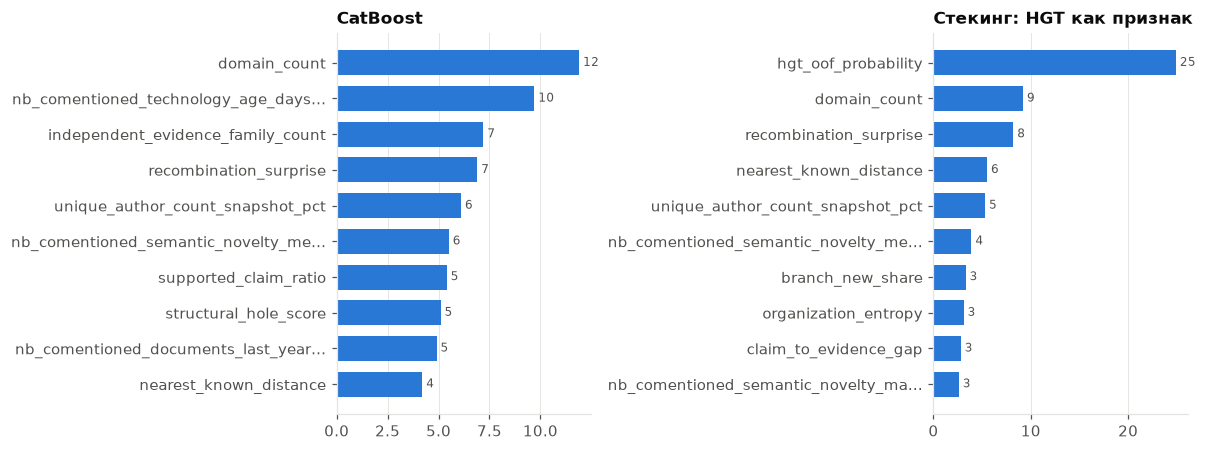

In [5]:
rows = {}
for name in ("catboost", "stacked"):
    model = CatBoostClassifier()
    model.load_model(str(MODELS_DIR / f"{name}.cbm"))
    params = model.get_all_params()
    rows[name] = (model, {"деревьев": model.tree_count_, "из максимума": params["iterations"],
                          "глубина": params["depth"], "шаг обучения": round(params["learning_rate"], 3),
                          "признаков": len(model.feature_names_)})
display(pd.DataFrame({ {"catboost": "CatBoost", "stacked": "стекинг HGT → CatBoost"}[k]: v[1]
                      for k, v in rows.items()}))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, (model, _)) in zip(axes, rows.items()):
    importance = pd.Series(model.get_feature_importance(), index=model.feature_names_)
    top = importance.sort_values(ascending=False).head(10)
    bar(ax, [short(i, 34) for i in top.index], top.values.round(1), horizontal=True)
    ax.set_title({"catboost": "CatBoost", "stacked": "Стекинг: HGT как признак"}[name])
plt.tight_layout()
plt.show()

## 5. Выводы

Считаются из таблиц выше.

In [6]:
trees = rows["catboost"][1]["деревьев"]
richer = share["«Список 100»"] - share["весь граф"]
more = ", ".join(f"«{v}»" for v in richer[richer > 0.02].index)
compare = "не выше, чем" if weak_list <= weak_graph * 1.2 else "выше, чем"
display(Markdown(f"""
1. **Покрытие.** Косинус ≥ 0,8 только у {int((bench.match_cosine >= 0.8).sum())} из {len(bench)} технологий списка,
   ≥ 0,85 — у {int((bench.match_cosine >= 0.85).sum())}. Большая часть сигналов методологов в графе представлена
   соседними, а не теми же технологиями: корпус (в основном научные статьи до 2026 года) их ещё не видит.
2. **Модель.** Средняя вероятность по сопоставленным — {scored.probability.mean():.2f}, максимум —
   {scored.probability.max():.2f}; выше порога модели — {int(scored.signal.fillna(0).sum())}. Модель в нынешнем виде
   **не узнаёт** сигналы методологов.
3. **LLM.** Вердикты {more} в списке встречаются чаще, чем по графу, и «не технологий» меньше — LLM видит,
   что это содержательные технологии. Но «слабый сигнал» в последнем году у {weak_list:.0%} технологий списка —
   {compare} у технологий графа в целом ({weak_graph:.0%}): по меркам разметки большинство из них уже ниша или мейнстрим.
4. **Почему.** Модель честно воспроизводит разметку, на которой училась (04, 06), но эта разметка понимает
   «слабый сигнал» уже, чем методологи: для LLM это технология ранней стадии без массового распространения
   *по нашему корпусу*, а в списке много технологий «раннего внедрения», о которых в статьях пишут давно.
5. **Устройство.** CatBoost остановился на {trees} деревьях из 800: сигнал в признаках есть, но слабый, и
   модель быстро начинает переобучаться. Главный признак стекинга — вероятность HGT, то есть графовое
   окружение добавляет информацию, которой нет в таблице.

**Что делать дальше:** (1) взять «Список 100» и экспертную разметку (бланки `review.reviewer_*.csv`)
как золотой набор для калибровки порога разметки; (2) добавить в корпус источники, где эти технологии
появляются раньше статей (патенты, репозитории, пресс-релизы); (3) подтвердить совпадения вручную в
пакете разметки — косинус 0,78 часто означает соседнюю тему.
"""))


1. **Покрытие.** Косинус ≥ 0,8 только у 32 из 100 технологий списка,
   ≥ 0,85 — у 3. Большая часть сигналов методологов в графе представлена
   соседними, а не теми же технологиями: корпус (в основном научные статьи до 2026 года) их ещё не видит.
2. **Модель.** Средняя вероятность по сопоставленным — 0.20, максимум —
   0.50; выше порога модели — 0. Модель в нынешнем виде
   **не узнаёт** сигналы методологов.
3. **LLM.** Вердикты «состоялась», «ниша», «мейнстрим» в списке встречаются чаще, чем по графу, и «не технологий» меньше — LLM видит,
   что это содержательные технологии. Но «слабый сигнал» в последнем году у 6% технологий списка —
   не выше, чем у технологий графа в целом (6%): по меркам разметки большинство из них уже ниша или мейнстрим.
4. **Почему.** Модель честно воспроизводит разметку, на которой училась (04, 06), но эта разметка понимает
   «слабый сигнал» уже, чем методологи: для LLM это технология ранней стадии без массового распространения
   *по нашему корпусу*, а в списке много технологий «раннего внедрения», о которых в статьях пишут давно.
5. **Устройство.** CatBoost остановился на 16 деревьях из 800: сигнал в признаках есть, но слабый, и
   модель быстро начинает переобучаться. Главный признак стекинга — вероятность HGT, то есть графовое
   окружение добавляет информацию, которой нет в таблице.

**Что делать дальше:** (1) взять «Список 100» и экспертную разметку (бланки `review.reviewer_*.csv`)
как золотой набор для калибровки порога разметки; (2) добавить в корпус источники, где эти технологии
появляются раньше статей (патенты, репозитории, пресс-релизы); (3) подтвердить совпадения вручную в
пакете разметки — косинус 0,78 часто означает соседнюю тему.
